In [16]:
import matplotlib.pyplot as plt

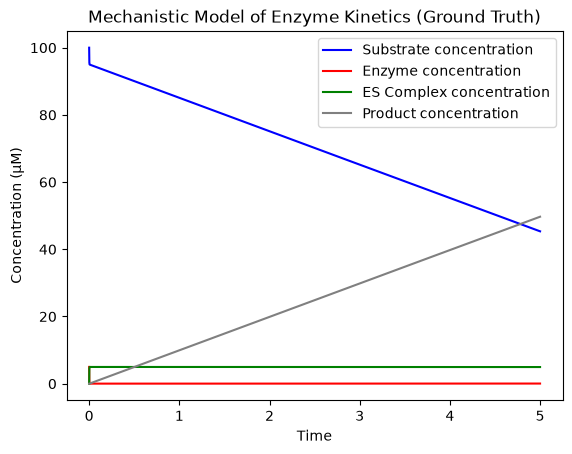

In [17]:
#Task 1 - Simulate the mechanistic model of a chemical reaction
#Variables used - Substrate (s), Enzyme (e), Complex (es), Product (p)
#Rate constants used - k1 (binding rate), k2 (dissociation rate), k3 (Catalysis)

s_conc = 100.0
e_conc = 5.0
p_conc = 0.0
es_conc = 0.0
dt = .0001
k1 = 10.0
k2 = k3 = 2.0
current_time = 0
time_coordinates = []
s_coordinates = []
e_coordinates = []
es_coordinates = []
p_coordinates = []
for i in range(50000):
    time_coordinates.append(current_time)
    s_coordinates.append(s_conc)
    e_coordinates.append(e_conc)
    es_coordinates.append(es_conc)
    p_coordinates .append(p_conc)
    ds = -(k1 * e_conc * s_conc * dt) + (k2 * es_conc * dt)
    de = -(k1 * e_conc * s_conc * dt) + (k2 * es_conc * dt) + (k3 * es_conc * dt)
    des = (k1 * e_conc * s_conc * dt) - (k2 * es_conc * dt) - (k3 * es_conc * dt)
    dp = (k3 * es_conc * dt)
    
    s_conc += ds
    e_conc += de
    es_conc += des
    p_conc += dp
    current_time += dt

plt.plot(time_coordinates, s_coordinates, label="Substrate concentration", color="blue")
plt.plot(time_coordinates, e_coordinates, label="Enzyme concentration", color="red")
plt.plot(time_coordinates, es_coordinates, label="ES Complex concentration", color="green")
plt.plot(time_coordinates, p_coordinates, label="Product concentration", color="grey")

plt.xlabel("Time")
plt.ylabel("Concentration (µM)")
plt.title("Mechanistic Model of Enzyme Kinetics (Ground Truth)")
plt.legend()
plt.show()




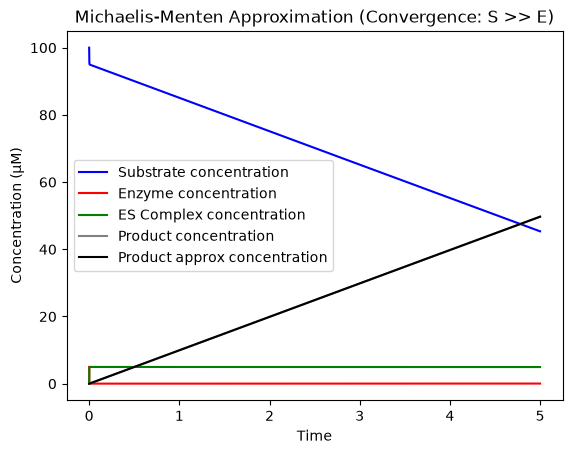

In [18]:
#Task 2 - Simulate the michael menten equation
#Substrate >> Enzyme

s_conc = 100.0
e_conc = 5.0
p_conc = 0.0
es_conc = 0.0
p_approx = 0.0
dt = .0001
k1 = 10.0
k2 = k3 = 2.0
km = (k2 + k3)/k1
current_time = 0
time_coordinates = []
s_coordinates = []
e_coordinates = []
es_coordinates = []
p_coordinates = []
p_approx_coordinates = []
for i in range(50000):
    time_coordinates.append(current_time)
    s_coordinates.append(s_conc)
    e_coordinates.append(e_conc)
    es_coordinates.append(es_conc)
    p_coordinates .append(p_conc)
    p_approx_coordinates.append(p_approx)
    ds = -(k1 * e_conc * s_conc * dt) + (k2 * es_conc * dt)
    de = -(k1 * e_conc * s_conc * dt) + (k2 * es_conc * dt) + (k3 * es_conc * dt)
    des = (k1 * e_conc * s_conc * dt) - (k2 * es_conc * dt) - (k3 * es_conc * dt)
    dp = (k3 * es_conc * dt)
    vmax = k3 * (e_conc + es_conc)
    v = (vmax * s_conc)/(km + s_conc)
    dp_approx = v * dt
    
    s_conc += ds
    e_conc += de
    es_conc += des
    p_conc += dp
    p_approx += dp_approx
    current_time += dt

plt.plot(time_coordinates, s_coordinates, label="Substrate concentration", color="blue")
plt.plot(time_coordinates, e_coordinates, label="Enzyme concentration", color="red")
plt.plot(time_coordinates, es_coordinates, label="ES Complex concentration", color="green")
plt.plot(time_coordinates, p_coordinates, label="Product concentration", color="grey")
plt.plot(time_coordinates, p_approx_coordinates, label="Product approx concentration", color="black")

plt.xlabel("Time")
plt.ylabel("Concentration (µM)")
plt.title("Michaelis-Menten Approximation (Convergence: S >> E)")
plt.legend()
plt.show()




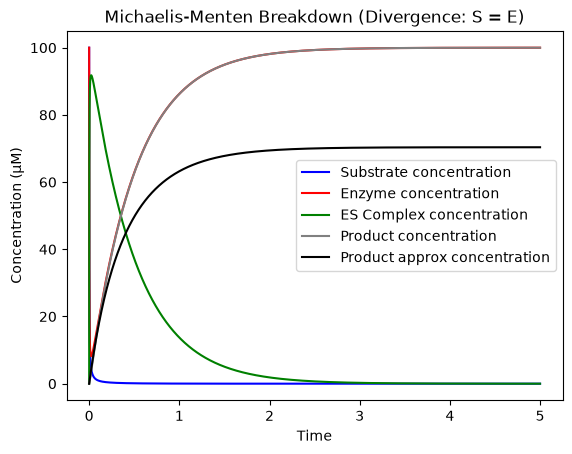

In [19]:
#Task 3 - Simulate the michael menten equation (Divergence)
#Putting enzyme and substrate initial concentration equal

s_conc = 100.0
e_conc = 100.0
p_conc = 0.0
es_conc = 0.0
p_approx = 0.0
dt = .0001
k1 = 10.0
k2 = k3 = 2.0
km = (k2 + k3)/k1
current_time = 0
time_coordinates = []
s_coordinates = []
e_coordinates = []
es_coordinates = []
p_coordinates = []
p_approx_coordinates = []
for i in range(50000):
    time_coordinates.append(current_time)
    s_coordinates.append(s_conc)
    e_coordinates.append(e_conc)
    es_coordinates.append(es_conc)
    p_coordinates .append(p_conc)
    p_approx_coordinates.append(p_approx)
    ds = -(k1 * e_conc * s_conc * dt) + (k2 * es_conc * dt)
    de = -(k1 * e_conc * s_conc * dt) + (k2 * es_conc * dt) + (k3 * es_conc * dt)
    des = (k1 * e_conc * s_conc * dt) - (k2 * es_conc * dt) - (k3 * es_conc * dt)
    dp = (k3 * es_conc * dt)
    vmax = k3 * (e_conc + es_conc)
    v = (vmax * s_conc)/(km + s_conc)
    dp_approx = v * dt
    
    s_conc += ds
    e_conc += de
    es_conc += des
    p_conc += dp
    p_approx += dp_approx
    current_time += dt

plt.plot(time_coordinates, s_coordinates, label="Substrate concentration", color="blue")
plt.plot(time_coordinates, e_coordinates, label="Enzyme concentration", color="red")
plt.plot(time_coordinates, es_coordinates, label="ES Complex concentration", color="green")
plt.plot(time_coordinates, p_coordinates, label="Product concentration", color="grey")
plt.plot(time_coordinates, p_approx_coordinates, label="Product approx concentration", color="black")

plt.xlabel("Time")
plt.ylabel("Concentration (µM)")
plt.title("Michaelis-Menten Breakdown (Divergence: S = E)")
plt.legend()
plt.show()


In [20]:
import matplotlib.pyplot as plt

def simulate_michael_menten(
    s_initial: float,
    e_initial: float,
    es_initial: float = 0.0,
    p_initial: float = 0.0,
    p_approx_initial: float = 0.0, 
    dt: float = 0.001, 
    k1: float = 10.0,
    k2: float = 2.0,
    k3: float = 2.0,
    steps: int = 10000
):
    print(f"s_initial={s_initial}, e_initial={e_initial}, k1={k1}, k2={k2}, k3={k3}")
    km = (k2 + k3) / k1
    print(f"km={km}")
    current_time = 0.0
    s_current = s_initial
    e_current = e_initial
    es_current = es_initial
    p_current = p_initial
    p_approx_current = p_approx_initial
    time_coordinates = []
    s_coordinates = []
    e_coordinates = []
    es_coordinates = []
    p_coordinates = []
    p_approx_coordinates = []
    print(f"e + es at start: {e_initial + es_initial}")

    for i in range(steps):
        time_coordinates.append(current_time)
        s_coordinates.append(s_current)
        e_coordinates.append(e_current)
        es_coordinates.append(es_current)
        p_coordinates .append(p_current)
        p_approx_coordinates.append(p_approx_current)
        ds = -(k1 * e_current * s_current * dt) + (k2 * es_current * dt)
        de = -(k1 * e_current * s_current * dt) + (k2 * es_current * dt) + (k3 * es_current * dt)
        des = (k1 * e_current * s_current * dt) - (k2 * es_current* dt) - (k3 * es_current * dt)
        dp = (k3 * es_current * dt)
        vmax = k3 * (e_current + es_current)
        v = (vmax * s_current)/(km + s_current)
        dp_approx = v * dt
        
        s_current += ds
        e_current += de
        es_current += des
        p_current += dp
        p_approx_current += dp_approx
        current_time += dt
    print(f"e + es at end: {e_current + es_current}")
    print(f"final product (mechanistic): {p_coordinates[-1]}")
    print(f"final product (approx): {p_approx_coordinates[-1]}")
    print(f"max substrate ever reached: {max(s_coordinates)}")
    return time_coordinates, s_coordinates, e_coordinates, es_coordinates, p_coordinates, p_approx_coordinates

def plot_result(time_coordinates, s_coordinates, e_coordinates, es_coordinates, p_coordinates, p_approx_coordinates):
    plt.plot(time_coordinates, s_coordinates, label="Substrate concentration", color="blue")
    plt.plot(time_coordinates, e_coordinates, label="Enzyme concentration", color="red")
    plt.plot(time_coordinates, es_coordinates, label="ES Complex concentration", color="green")
    plt.plot(time_coordinates, p_coordinates, label="Product concentration", color="grey")
    plt.plot(time_coordinates, p_approx_coordinates, label="Product approx concentration", color="black")

    plt.xlabel("Time")
    plt.ylabel("Concentration (µM)")
    plt.title("Enzyme Kinetics Over Time")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

In [21]:
#When substrate is larger than enzyme
time_coord, s_coord, e_coord, es_coord, p_coord, p_approx_coord = simulate_michael_menten(s_initial= 100.0,e_initial= 5.0, es_initial= 0.0, p_initial= 0.0, p_approx_initial= 0.0, dt = 0.001, 
    k1 = 10.0,
    k2 = 2.0,
    k3 = 2.0,
    steps = 50000)

s_initial=100.0, e_initial=5.0, k1=10.0, k2=2.0, k3=2.0
km=0.4
e + es at start: 5.0
e + es at end: 4.999999999999865
final product (mechanistic): 99.99999999999726
final product (approx): 98.58178117751945
max substrate ever reached: 100.0


In [22]:
#When enzyme is larger than substrate concentration
time_coord, s_coord, e_coord, es_coord, p_coord, p_approx_coord = simulate_michael_menten(s_initial= 100.0,e_initial= 200.0, es_initial= 0.0, p_initial= 0.0, p_approx_initial= 0.0, dt = 0.001, 
    k1 = 10.0,
    k2 = 2.0,
    k3 = 2.0,
    steps = 50000)

s_initial=100.0, e_initial=200.0, k1=10.0, k2=2.0, k3=2.0
km=0.4
e + es at start: 200.0
e + es at end: 200.0
final product (mechanistic): 100.20632771989676
final product (approx): 11277.947590468802
max substrate ever reached: 100.0


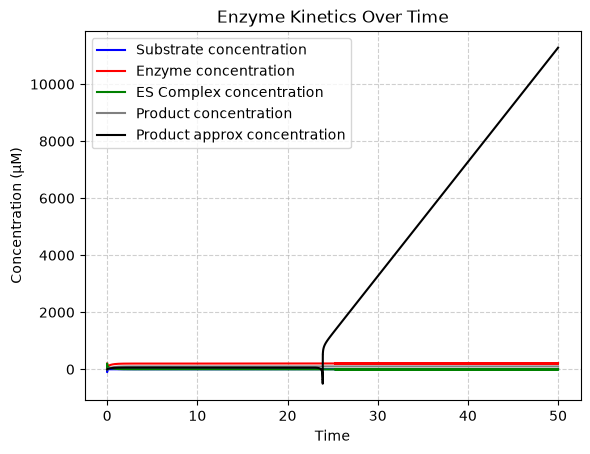

In [23]:
plot_result(time_coord, s_coord, e_coord, es_coord, p_coord, p_approx_coord)